# The samples are not on a grid, and that is the whole problem

[`01_build.ipynb`](01_build.ipynb) wrote two radial `.seq` files and checked that every spoke goes
where it was asked to. It never reconstructed anything, because a radial acquisition cannot be
inverse-Fourier-transformed: **its samples do not sit on the grid an FFT assumes.**

This notebook is the introduction to the non-Cartesian path that
[`../noncartesian_recon.py`](../noncartesian_recon.py) implements, and to the one line in it that
matters:

```text
physical k [1/m]  x  FOV [m]  ->  cycles per FOV  ->  sigpy `coord`
```

| | |
|---|---|
| **1. why not `ifft2`** | 4096 samples for a 4096-point grid, and a third of the grid has nothing within half a Δk of it |
| **2. where the trajectory enters** | the file is parsed by the *simulator*, and the k it reports drives the reconstruction. Checked by putting a point somewhere known and finding it |
| **3. density compensation** | what it buys, and the thing it is routinely assumed to be and is not |
| **4. one inverse problem** | the adjoint decomposes over spokes. The solve does not, and the difference is 0.07 against 0.97 |
| **5. ordering is a contract** | the reconstruction pairs sample *n* of the trajectory with sample *n* of the data, and nothing checks that for you |

The adapter itself is **not** re-proved here. `tests/examples/test_noncartesian_recon.py` checks it
against an explicit dense DFT that calls no SigPy, and that is where a reader should look for the
numerical foundation. What this notebook adds is the part a unit test cannot: real simulated data,
from the file a scanner would be given.

In [1]:
import os

# Set before torch is imported, which is where it reads them.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph                                    # noqa: E402 -- the shared BrainWeb slab
from noncartesian_recon import (                        # noqa: E402 -- the shared contract
    NonCartesianAcquisition, dcf, reconstruct, sigpy_coord,
)

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

#: `01_build.ipynb`'s protocol.  Repeated rather than imported: a reconstruction that reads its
#: geometry from the notebook that wrote the file is not reconstructing the file.
FOV_M, MATRIX, SPOKES = 0.260, 64, 64
SEQ_DIR = Path('seq')
PIXEL_M = FOV_M / MATRIX

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Why not `ifft2`

The file is read back with **MRzero's own parser** — never the `LogicBlock` tree that produced it.
A `.seq` is what a scanner is given, and the point of reconstructing one is that nothing upstream
of the file is consulted.

`get_kspace()` hands back `(kx, ky, kz, t)` per ADC sample, in **1/m and seconds**, computed by
integrating the gradients in the file. That is an independent measurement of the trajectory, from a
codebase that shares nothing with `RadialReadout`.

In [2]:
imported = mr0.Sequence.import_file(str(SEQ_DIR / 'gre_radial_2d_equal.seq'))
sampled = imported.get_kspace().numpy()
NS = sampled.shape[0] // SPOKES

# (shots, 2, samples), in acquisition order -- the shape the shared contract takes.
k_per_m = sampled[:, :2].reshape(SPOKES, NS, 2).transpose(0, 2, 1)
# Sample times from the start of the readout, which is the origin `echo_times_s` uses too.  Every
# spoke has the same internal timing, so one row serves all of them.
t_adc_s = sampled[:NS, 3] - sampled[0, 3]
CENTRE = MATRIX // 2                       # the sample `RadialReadout` puts exactly on k = 0

print(f'{SPOKES} spokes x {NS} samples = {SPOKES * NS} samples, for a '
      f'{MATRIX} x {MATRIX} = {MATRIX ** 2} grid')
print(f'|k| reaches {np.hypot(k_per_m[:, 0], k_per_m[:, 1]).max():.2f} 1/m '
      f'(matrix / 2 FOV = {MATRIX / (2 * FOV_M):.2f})')
print(f'|kz|        {np.abs(sampled[:, 2]).max():.2e} 1/m')
print(f'|k| at sample {CENTRE} '
      f'{np.hypot(k_per_m[:, 0, CENTRE], k_per_m[:, 1, CENTRE]).max():.2e} 1/m   <- on the origin')

64 spokes x 64 samples = 4096 samples, for a 64 x 64 = 4096 grid
|k| reaches 123.08 1/m (matrix / 2 FOV = 123.08)
|kz|        1.40e-03 1/m
|k| at sample 32 3.25e-04 1/m   <- on the origin


### The sampling fact, before any reconstruction

There are exactly as many samples as grid points. That is the trap: the counts match, the array is
`(64, 64)`, and `np.fft.ifft2` will accept it without complaint.

In [3]:
grid_1d = (np.arange(MATRIX) - MATRIX // 2) / FOV_M
grid = np.stack(np.meshgrid(grid_1d, grid_1d, indexing='ij'), axis=-1).reshape(-1, 2)
flat = np.moveaxis(k_per_m, 1, -1).reshape(-1, 2)
# Chebyshev distance to the nearest sample, in 1/m: how far a grid point is from anything measured.
nearest = np.abs(grid[:, None, :] - flat[None, :, :]).max(axis=-1).min(axis=1)

print(f'grid points with no sample within half a dk   '
      f'{(nearest > 0.5 / FOV_M).mean() * 100:.1f} %')
print(f'worst distance to the nearest sample          '
      f'{nearest.max() * FOV_M:.2f} dk')
print()
print('The samples are dense at the centre, where 64 spokes all pass through the origin, and')
print('sparse at the edge, where the same 64 spokes have fanned out.  Both facts are why the')
print('counts matching means nothing.')

grid points with no sample within half a dk   34.0 %
worst distance to the nearest sample          10.08 dk

The samples are dense at the centre, where 64 spokes all pass through the origin, and
sparse at the edge, where the same 64 spokes have fanned out.  Both facts are why the
counts matching means nothing.


### A known object, sampled exactly

Everything quantitative below uses an object whose k-space is evaluated **by direct summation at
the sample positions** — $\sum_r x(r)\,e^{-2\pi i k\cdot r}$, no FFT and no simulator. So the truth
is exact and the only thing under test is the reconstruction.

The brain in §6 is the illustration; the simulator appears in §2, where it has a job no synthetic
object can do.

In [4]:
axis_m = (np.arange(MATRIX) - MATRIX // 2) * PIXEL_M
X_M, Y_M = np.meshgrid(axis_m, axis_m, indexing='ij')

TRUTH = np.zeros((MATRIX, MATRIX))
TRUTH[(X_M ** 2 + Y_M ** 2) < 0.070 ** 2] = 1.0
TRUTH[(np.abs(X_M - 0.020) < 0.012) & (np.abs(Y_M + 0.030) < 0.030)] = 0.4
TRUTH[((X_M + 0.035) ** 2 + (Y_M - 0.025) ** 2) < 0.012 ** 2] = 1.8


def exact_kspace(k, image=TRUTH):
    """What a receiver sampling at `k` would record from `image`.  A sum over the object."""
    basis = np.exp(-2j * np.pi * (k[:, 0][..., None] * X_M.ravel()
                                  + k[:, 1][..., None] * Y_M.ravel()))
    return basis @ image.ravel().astype(complex)


def nrmse(image, truth=TRUTH):
    """Error against `truth` after the best single scale factor, so overall gain is free."""
    magnitude = np.abs(image)
    scale = float((magnitude * truth).sum() / max((magnitude ** 2).sum(), 1e-30))
    return float(np.linalg.norm(scale * magnitude - truth) / np.linalg.norm(truth))


MEASURED = exact_kspace(k_per_m)
print(f'object: a disc, a bar and a bright dot on a {MATRIX} x {MATRIX} grid')
print(f'exact k-space at the {MEASURED.size} radial sample positions, shape {MEASURED.shape}')

object: a disc, a bar and a bright dot on a 64 x 64 grid
exact k-space at the 4096 radial sample positions, shape (64, 64)


### What `ifft2` does with it

Treating the `(spokes, samples)` array as if it were a k-space grid. It is the reflex, it runs, and
it returns an image-shaped array.

In [5]:
naive = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(MEASURED)))
print(f'ifft2 of the raw (spokes, samples) array   nrmse {nrmse(naive):.4f}')
print()
print('For scale: a black image scores 1.00, and the reconstruction in section 3 scores 0.07.')

ifft2 of the raw (spokes, samples) array   nrmse 0.9719

For scale: a black image scores 1.00, and the reconstruction in section 3 scores 0.07.


---
## 2. Where the trajectory enters, and how to know it entered correctly

The whole adapter is one multiplication. SigPy's `coord` counts **cycles across the reconstructed
field of view**, so a sample at $k_{\max} = N/(2\,\mathrm{FOV})$ must land at $N/2$, the edge of an
$N$-point grid. Multiplying physical k by the FOV is exactly that change of units — no sign, no
transpose, no offset.

Everything that could be wrong here produces an image that still looks like an image.

In [6]:
acquisition = NonCartesianAcquisition(
    k_per_m=k_per_m, t_adc_s=t_adc_s, fov_m=FOV_M, matrix=MATRIX,
    # Explicit.  The centre sample *is* the echo for a full radial spoke, and inferring that from
    # the data would be right here and wrong for every trajectory in the next two notebooks.
    echo_times_s=(float(t_adc_s[CENTRE]),),
)
coord = sigpy_coord(acquisition)

print(f'k_per_m   {np.abs(k_per_m).max():8.2f} 1/m')
print(f'coord     {np.abs(coord).max():8.2f} cycles per FOV   (matrix / 2 = {MATRIX / 2:.0f})')
print(f'shape     {coord.shape}   (shots, samples, 2) -- sigpy reads the axis last')

k_per_m     123.08 1/m
coord        32.00 cycles per FOV   (matrix / 2 = 32)
shape     (64, 64, 2)   (shots, samples, 2) -- sigpy reads the axis last


### The check that a magnitude image cannot do

Put a point somewhere known and see where it comes back. A scale error, a swapped axis, a sign flip
and a half-pixel origin shift all survive a look at a brain; none of them survives this.

The point is simulated, not synthesised — `CustomVoxelPhantom` takes positions in **metres**, and
the simulator plays the same file, so this measures the whole path end to end.

In [7]:
def point_at(x_m, y_m):
    """Simulate one voxel at (x, y) metres through the imported file."""
    built = mr0.CustomVoxelPhantom(
        pos=[[float(x_m), float(y_m), 0.0]], PD=[1.0], T1=[1.0], T2=[0.1], T2dash=[0.05],
        D=[0.0], voxel_size=PIXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0                    # B0 = 0: off-resonance is section 2 of
    built.B1 = built.B1.float() * 0.0 + 1.0              # the *spiral* notebook, not this one
    graph = mr0.compute_graph(imported, built, max_state_count=64, min_state_mag=1e-4)
    signal = mr0.execute_graph(graph, imported, built, print_progress=False)
    return np.asarray(signal).reshape(SPOKES, NS)


weights = dcf(acquisition, method='pipe')
print(f'{"object x, y / px":>18}   {"peak row, col":>15}   {"predicted":>12}')
for dx, dy in ((0, 0), (8, 0), (0, -12), (-5, 11)):
    image = np.abs(reconstruct(point_at(dx * PIXEL_M, dy * PIXEL_M), acquisition,
                               weights=weights, use='preconditioner', iterations=30))
    row, col = np.unravel_index(int(np.argmax(image)), image.shape)
    print(f'{dx:+8d}, {dy:+6d}   {row:7d}, {col:6d}   '
          f'{MATRIX // 2 + dx:6d}, {MATRIX // 2 + dy:4d}')

  object x, y / px     peak row, col      predicted
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0002695 s
Compute Graph
Computing Graph: 0.007488792 s
Analyze Graph
Analyzing Graph: 0.00008475 s
Converting Rust -> Python: 0.002593333 s
<<<< Rust <<<<


      +0,     +0        32,     32       32,   32
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000324458 s
Compute Graph
Computing Graph: 0.007540125 s
Analyze Graph
Analyzing Graph: 0.000081625 s
Converting Rust -> Python: 0.002533292 s
<<<< Rust <<<<
      +8,     +0        40,     32       40,   32
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000216125 s
Compute Graph
Computing Graph: 0.007557 s
Analyze Graph
Analyzing Graph: 0.000078375 s
Converting Rust -> Python: 0.002421916 s
<<<< Rust <<<<


      +0,    -12        32,     20       32,   20
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00022175 s
Compute Graph
Computing Graph: 0.0074585 s
Analyze Graph
Analyzing Graph: 0.000074375 s
Converting Rust -> Python: 0.002482792 s
<<<< Rust <<<<
      -5,    +11        27,     43       27,   43


### The convention that comes out of that table, and it is not the suite's usual one

**A displacement in `x` moved the peak along the row axis, and a displacement in `y` along the
column axis.** So this image is indexed `[x, y]`.

Every Cartesian `02` in this repository reconstructs `[ky, kx] = [y, x]` and draws it with no
transform, and [`../phantom.py`](../phantom.py)`.same_frame` exists to put a phantom map — which is
`[x, y]` — into that frame. A non-Cartesian reconstruction comes out in the **phantom's** frame
instead, because SigPy maps `coord[..., 0]` to image axis 0 and `coord[..., 0]` is $k_x$.

So here `same_frame` is applied to the *reconstruction* as well, and the reason is worth stating
plainly: this is a property of the adapter's axis order, not a fact about radial sampling. It would
be equally easy to build `coord` as $(k_y, k_x)$ and get the other frame. What must not happen is
that nobody checks — and a magnitude brain image is very nearly symmetric enough to hide it.

---
## 3. Density compensation — what it buys, and what it is not

The adjoint $A^H y$ is not the inverse. For a radial acquisition it is badly wrong in a specific
way: 64 spokes all pass through the origin, so the centre of k-space is measured 64 times and the
edge once. $A^H$ sums them, and the low frequencies come out 64 times too strong.

Density compensation is a weight $w$ that undoes that **sampling** imbalance. Pipe–Menon estimates
it iteratively from the trajectory alone; $|k|$ is its analytic value for uniform radial spokes and
is useful precisely because it is *not* right here, for a reason the numbers will show.

In [8]:
w_pipe = dcf(acquisition, method='pipe')
w_radial = dcf(acquisition, method='radial')

print(f'{"":26s} {"nrmse":>7s}')
for label, kwargs in (
        ('adjoint, no weights', dict(weights=None, use='none', iterations=0)),
        ('gridding, |k|', dict(weights=w_radial, use='gridding')),
        ('gridding, Pipe-Menon', dict(weights=w_pipe, use='gridding')),
        ('CG 30, unpreconditioned', dict(weights=None, use='none', iterations=30)),
        ('CG 30, preconditioned', dict(weights=w_pipe, use='preconditioner', iterations=30)),
        ('CG 30, data-weighted', dict(weights=w_pipe, use='data', iterations=30))):
    print(f'{label:26s} {nrmse(reconstruct(MEASURED, acquisition, **kwargs)):7.4f}')

                             nrmse


adjoint, no weights         0.6380
gridding, |k|               0.3515
gridding, Pipe-Menon        0.1912
CG 30, unpreconditioned     0.0728


CG 30, preconditioned       0.0725
CG 30, data-weighted        0.0725


Two things in that table, and the second is the one that gets assumed away.

**Density compensation makes the adjoint usable.** 0.64 to 0.19 for one extra multiply, and $|k|$
gets less than half of that improvement — it is exact for the *continuous* radial density and this
trajectory has 64 discrete spokes with a finite sample spacing along each, so the true density is
not $|k|$ near the origin. That is the useful failure: an analytic weight is a statement about an
idealisation, and Pipe–Menon measures the trajectory that exists.

**Density compensation is not the inverse, and on this data it does not change the converged
answer either.** The three CG rows agree to 0.0003 — and the reason is worth being exact about,
because the obvious explanation is wrong.

`use='preconditioner'` and `use='data'` are **the same estimator**. Both assemble
$A^H W A\,x = A^H W y$, since $(W^{1/2}A)^H(W^{1/2}A) = A^HWA$; the names, inherited from the
historical work, suggest a difference that does not exist, and
`tests/examples/test_noncartesian_recon.py` pins them as identical on the operator itself. Neither
is a preconditioner in the numerical sense — a preconditioner leaves the fixed point where it was,
and a weight moves it.

They agree with the *unweighted* row for a different reason: this data is **noiseless and
consistent**, so every one of these solves can drive the residual to zero, and a weight cannot
change where zero is. Add noise and they separate. What the weights buy here is therefore the
*path*:

In [9]:
print(f'{"iterations":>10}  {"preconditioned":>14}  {"plain CG":>9}')
for n in (1, 3, 5, 10, 20, 30, 60):
    fast = nrmse(reconstruct(MEASURED, acquisition, weights=w_pipe,
                             use='preconditioner', iterations=n))
    slow = nrmse(reconstruct(MEASURED, acquisition, weights=None, use='none', iterations=n))
    print(f'{n:10d}  {fast:14.4f}  {slow:9.4f}')

iterations  preconditioned   plain CG
         1          0.1912     0.6380
         3          0.0917     0.2321


         5          0.0830     0.1451
        10          0.0740     0.0759


        20          0.0726     0.0728


        30          0.0725     0.0728


        60          0.0726     0.0727


Both converge to the same place. The weighted solve is there by about iteration 5; the unweighted
one needs around 20. **On this data the weights are a speed choice**, and calling them a
"reconstruction improvement" confuses a better estimator with a faster route to the same one.

They stop being only a speed choice as soon as the data are inconsistent. With noise the residual
cannot be driven to zero, the weights decide *which* residual is minimised, and the weighted and
unweighted answers genuinely part company —
`tests/examples/test_noncartesian_recon.py::test_weighting_matters_only_when_the_data_are_inconsistent`
measures both regimes. That is the honest form of the claim, and a first version of this notebook
made the stronger one.

> **What none of this establishes.** That Pipe–Menon is the optimal weight, that 30 iterations is
> the right number, that CG is the right solver, or that any of it survives coil sensitivities,
> noise or a trajectory that differs from the one in the file. Those are separate measurements and
> this notebook does not make them.

---
## 4. The spokes are one inverse problem

Each spoke is a complete pass through the centre of k-space, which makes it tempting to treat as a
small reconstruction of its own. Whether that is wrong depends on which operator is meant, and the
two halves come out opposite ways.

In [10]:
def one_spoke(index):
    """The same acquisition description, restricted to a single spoke."""
    return NonCartesianAcquisition(
        k_per_m=k_per_m[index:index + 1], t_adc_s=t_adc_s, fov_m=FOV_M, matrix=MATRIX,
        echo_times_s=(float(t_adc_s[CENTRE]),))


joint_adjoint = reconstruct(MEASURED, acquisition, weights=w_pipe, use='gridding')
summed_adjoint = sum(reconstruct(MEASURED[s:s + 1], one_spoke(s), weights=w_pipe[s:s + 1],
                                 use='gridding') for s in range(SPOKES))

joint_solve = reconstruct(MEASURED, acquisition, weights=w_pipe,
                          use='preconditioner', iterations=30)
summed_solve = sum(reconstruct(MEASURED[s:s + 1], one_spoke(s), weights=dcf(one_spoke(s)),
                               use='preconditioner', iterations=30) for s in range(SPOKES))

print(f'the ADJOINT decomposes: joint against the sum of {SPOKES} separate ones, '
      f'max |difference| {np.abs(joint_adjoint - summed_adjoint).max():.1e}')
print()
print(f'the SOLVE does not:  joint CG                 nrmse {nrmse(joint_solve):.4f}')
print(f'                     each spoke solved alone  nrmse {nrmse(summed_solve):.4f}')

the ADJOINT decomposes: joint against the sum of 64 separate ones, max |difference| 1.9e-11

the SOLVE does not:  joint CG                 nrmse 0.0725
                     each spoke solved alone  nrmse 0.9691


$A^H$ is linear in the data, so gridding spoke by spoke and adding is **exactly** joint gridding —
to 1e-11, which is floating point. Nothing is lost, and a pipeline that accumulates spokes as they
arrive is doing the right thing.

The solve is not linear in that sense. $A^HA$ is not block-diagonal over spokes: spoke $i$ and
spoke $j$ constrain the same pixels, and it is precisely that overlap which makes 4096 scattered
samples determine 4096 unknowns. Solve each spoke alone and each sub-problem is wildly
under-determined — one spoke constrains one line through k-space — so each returns something close
to its own streak, and the sum of 64 streaks is not an image.

This is why [`../noncartesian_recon.py`](../noncartesian_recon.py)`.encoding_operator` maps one
image to *all* shots at once, and why that is written down in its docstring rather than left as an
implementation detail.

---
## 5. Ordering is a contract, and nothing enforces it

`reconstruct` pairs sample $n$ of `k_per_m` with sample $n$ of the data. Both are in acquisition
order and neither carries a label, so a reordering of one is not an error — it is a different, and
wrong, answer.

In [11]:
shuffled = np.random.default_rng(0).permutation(NS)
spoke_order = np.random.default_rng(1).permutation(SPOKES)
variants = {
    'as acquired': (MEASURED, acquisition),
    'samples reversed within each spoke': (MEASURED[:, ::-1], acquisition),
    'samples shuffled within each spoke': (MEASURED[:, shuffled], acquisition),
    'spoke order shuffled, trajectory not': (MEASURED[spoke_order], acquisition),
    # The control: the same permutation applied to *both* sides.
    'spokes and trajectory permuted together': (
        MEASURED[spoke_order],
        NonCartesianAcquisition(k_per_m=k_per_m[spoke_order], t_adc_s=t_adc_s, fov_m=FOV_M,
                                matrix=MATRIX, echo_times_s=(float(t_adc_s[CENTRE]),))),
}
solved = {name: reconstruct(data, where, weights=dcf(where, method='pipe'),
                            use='preconditioner', iterations=30)
          for name, (data, where) in variants.items()}
for name, image in solved.items():
    print(f'{name:41s} nrmse {nrmse(image):.4f}')
print()
print(f'the last two use the same data; they differ only in whether the trajectory was permuted '
      f'with it.')
print(f'permuted together, against not permuted at all: max |difference| '
      f'{np.abs(solved["spokes and trajectory permuted together"] - solved["as acquired"]).max():.1e}')

as acquired                               nrmse 0.0725
samples reversed within each spoke        nrmse 0.6824
samples shuffled within each spoke        nrmse 0.8684
spoke order shuffled, trajectory not      nrmse 0.3544
spokes and trajectory permuted together   nrmse 0.0725

the last two use the same data; they differ only in whether the trajectory was permuted with it.
permuted together, against not permuted at all: max |difference| 7.5e-14


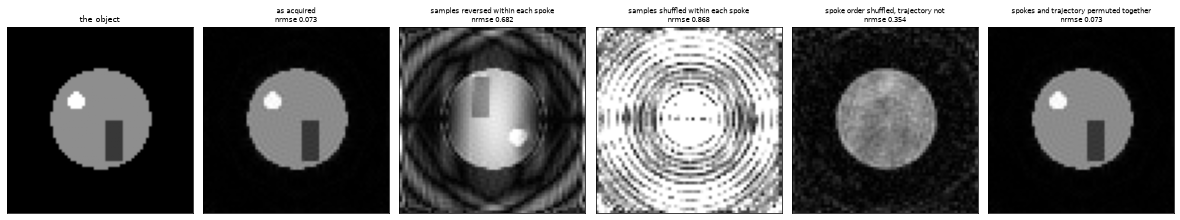

In [12]:
fig, axes = plt.subplots(1, len(solved) + 1, figsize=(3.0 * (len(solved) + 1), 3.2))
axes[0].imshow(ph.same_frame(TRUTH), cmap='gray', origin='lower')
axes[0].set_title('the object', fontsize=9)
ceiling = float(np.percentile(np.abs(solved['as acquired']), 99.8))
for ax, (name, image) in zip(axes[1:], solved.items()):
    # same_frame because a non-Cartesian reconstruction is [x, y] -- see section 2.
    ax.imshow(ph.same_frame(np.abs(image)), cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
    ax.set_title(f'{name}\nnrmse {nrmse(image):.3f}', fontsize=8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

Reversing is the interesting one. A radial spoke is symmetric about the origin, so a reversed spoke
lands on **the same set of k positions** — the trajectory is still exactly right, every sample is
still a real measurement, and the acquisition looks untouched. What changed is which measurement is
attributed to which position.

The last two rows are the contract stated exactly. **It is not the order that matters, it is the
pairing.** Permute the spokes and the trajectory together and the reconstruction is unchanged to
1e-13 — so a pipeline is free to sort, bin or stream its shots in any order it likes, as long as
the trajectory travels with them. Permute only the data and the image is gone, with no error
raised, because both arrays still have the shape the contract asks for.

A first draft of this section asserted that the spoke permutation was harmless *on its own*,
reasoning that the operator sums over the shots axis. The measurement says 0.354, and the reasoning
was wrong: each shot carries its own row of `coord`, so the sum is over pairs and permuting one
side of a pair is not a symmetry of it. It is recorded here because that is precisely the kind of
plausible mistake this section exists to make visible.

---
## 6. A brain, played through the same file

Everything above is a number on an object whose k-space was evaluated exactly. This is the
illustration: BrainWeb, simulated through the imported `.seq`, one coil, shimmed.

It reconstructs the **T1-weighted gradient echo the sequence actually produces**, which is why
there is no error metric here — the proton-density map is not what this protocol measures, and
scoring against it would grade the contrast rather than the reconstruction.

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000476917 s
Compute Graph
Computing Graph: 0.007504875 s
Analyze Graph
Analyzing Graph: 0.000090541 s
Converting Rust -> Python: 0.002561791 s
<<<< Rust <<<<


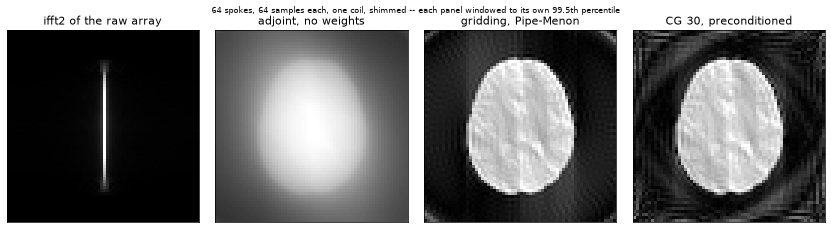

In [13]:
brain = ph.built(matrix=MATRIX, nz=1, z_center=64, n_coils=0, field_hz=0.0)
graph = mr0.compute_graph(imported, brain, max_state_count=64, min_state_mag=1e-4)
raw = np.asarray(mr0.execute_graph(graph, imported, brain,
                                   print_progress=False)).reshape(SPOKES, NS)

images = {
    'ifft2 of the raw array': np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(raw))),
    'adjoint, no weights': reconstruct(raw, acquisition, weights=None, use='none', iterations=0),
    'gridding, Pipe-Menon': reconstruct(raw, acquisition, weights=w_pipe, use='gridding'),
    'CG 30, preconditioned': reconstruct(raw, acquisition, weights=w_pipe,
                                         use='preconditioner', iterations=30),
}

fig, axes = plt.subplots(1, len(images), figsize=(3.2 * len(images), 3.5))
for ax, (name, image) in zip(axes, images.items()):
    shown = ph.same_frame(np.abs(image))
    ax.imshow(shown, cmap='gray', origin='lower', vmin=0.0,
              vmax=float(np.percentile(shown, 99.5)))
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle('64 spokes, 64 samples each, one coil, shimmed -- each panel windowed to its own 99.5th '
             'percentile', fontsize=9)
fig.tight_layout()

The second and third panels are the same data through the same adjoint, differing only by a
per-sample weight, and the difference between them is §3's 0.64 against 0.19. The fourth is what
30 conjugate-gradient iterations add on top.

The streaks in the last panel are real and are not a reconstruction failure: 64 spokes at a
64-matrix is about a factor $\pi/2$ short of the Nyquist spoke count, and undersampled radial
aliasing is streaks rather than the fold-over a Cartesian acquisition gives. That is a property of
the acquisition [`01`](01_build.ipynb) wrote, not of the solve.

---
## What this notebook measured

| | |
|---|---|
| **as many samples as grid points, and a third of the grid empty** | the counts match and mean nothing; `ifft2` of the raw array scores 0.97 where a black image scores 1.00 |
| **the trajectory comes from the file** | MRzero's parser integrates the gradients and reports k in 1/m; the adapter is that times the FOV, and nothing else |
| **a point comes back where it was put** | four positions, exact pixel agreement — and the table is what says the image is indexed `[x, y]`, unlike every Cartesian reconstruction in this repository |
| **density compensation makes the adjoint usable** | 0.638 to 0.191, and the analytic `\|k\|` weight gets less than half of that because the true density of 64 discrete spokes is not `\|k\|` |
| **on noiseless data the weights are a speed choice** | weighted and unweighted CG agree to 0.0003 at convergence because both drive the residual to zero; the weighted one arrives around iteration 5 instead of 20. `use='preconditioner'` and `use='data'` are **the same estimator**, `A^H W A x = A^H W y` — the names say otherwise and the test pins them as identical |
| **the adjoint decomposes over spokes and the solve does not** | 1e-11 against 0.0725 versus 0.9691 — the overlap between spokes is what makes the problem determined |
| **it is the pairing, not the order** | permuting spokes *and* trajectory together changes the image by 1e-13; permuting only the data scores 0.354, and reversing samples within a spoke keeps every k position and every measurement and still scores 0.682 |

**What it does not establish:** anything about a real scanner. The trajectory here is the one the
file encodes, played by a simulator that honours it exactly. Gradient delays, eddy currents, timing
errors, concomitant fields and receive-chain delays all move the *actual* k away from the nominal
one, and every one of them shows up as blurring or streaking that looks like a reconstruction
problem. Measuring them needs a scanner, and none of the numbers above is evidence about it.

Nor does it establish that Pipe–Menon, 30 iterations or conjugate gradient are the right choices —
only that the first is much better than no weight and that the second two have converged. And the
weighting comparison above is on **noiseless** data; the regime where the choice of weighted
against unweighted actually changes the answer is the noisy one, which is measured in the test
suite rather than here.

Next: [`../gre_spiral_2d/02_simulate_and_reconstruct.ipynb`](../gre_spiral_2d/02_simulate_and_reconstruct.ipynb)
keeps this machinery unchanged and adds the one thing a radial spoke is too short to show — a
readout long enough that off-resonance evolves *during* it.